# Sleep Health and Lifestyle Analysis with Machine Learning

### Problem: predict Sleep Disorder (None / Insomnia / Sleep Apnea) from lifestyle & health features.


In [3]:

# Basic imports
import pandas as pd
import numpy as np
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


In [4]:

# Loading dataset
DATA_PATH = "C:/Users/KOMAL/Desktop/Projects/Sleep_Health_and_Lifestyle_Analysis/Sleep_health_and_lifestyle_dataset.csv"

df1 = pd.read_csv(DATA_PATH)
df=df1.copy()


In [5]:
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
display(df.head())
print(df.info())
print(df.isna().sum())


Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None
Person ID        

In [6]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [7]:
df["Occupation"].unique()

array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

In [8]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [9]:
print(df["BMI Category"].unique())
df["BMI Category"].value_counts()

['Overweight' 'Normal' 'Obese' 'Normal Weight']


BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [10]:
# Replacing "Normal Weight" with "Normal" in the BMI Category
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")


print(df["BMI Category"].unique())
df["BMI Category"].value_counts()

['Overweight' 'Normal' 'Obese']


BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

In [11]:

# Clean Sleep Disorder
df['Sleep Disorder'] = df['Sleep Disorder'].replace('', np.nan)
print("Missing Sleep Disorder count:", df['Sleep Disorder'].isna().sum())


Missing Sleep Disorder count: 219


In [12]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [13]:
# Rule-based imputation for missing Sleep Disorder 
def fill_rule(row):
    if pd.isna(row['Sleep Disorder']):
        bmi = str(row['BMI Category']).strip()
        bp = str(row['Blood Pressure']).strip().lower()  # e.g., 'Normal', 'High', etc.
        age = float(row['Age'])
        stress = float(row['Stress Level'])
        quality = float(row['Quality of Sleep'])
        duration = float(row['Sleep Duration'])
        activity = float(row['Physical Activity Level'])  # in hours per week
        occupation = str(row['Occupation']).strip().lower()

        # ---- Sleep Apnea ----
        if (
            bmi in ['Overweight', 'Obese']
            and ('high' in bp or 'stage' in bp)  # handle BP text variations
            and age >= 40
            and activity < 3
        ):
            return 'Sleep Apnea'

        # ---- Insomnia ----
        elif (
            stress >= 7
            and duration < 6
            and quality <= 5
            and any(word in occupation for word in ['manager', 'executive', 'doctor', 'engineer', 'sales', 'teacher'])
        ):
            return 'Insomnia'

        # ---- No Disorder ----
        elif (
            bmi == 'Normal'
            and 'normal' in bp
            and 6 <= duration <= 8
            and quality >= 7
            and activity >= 3
        ):
            return 'No Disorder'

        # ---- Fallback rules ----
        elif bmi in ['Overweight', 'Obese'] and stress >= 7:
            return 'Sleep Apnea'
        elif duration < 6 or quality <= 5:
            return 'Insomnia'
        else:
            return 'No Disorder'

    else:
        return row['Sleep Disorder']


# Apply rule-based filling
df['Sleep Disorder'] = df.apply(fill_rule, axis=1)

# Check results
print(df['Sleep Disorder'].value_counts())


Sleep Disorder
No Disorder    215
Sleep Apnea     82
Insomnia        77
Name: count, dtype: int64


In [14]:

# Parse Blood Pressure
def parse_bp(bp):
    try:
        if pd.isna(bp): return (np.nan, np.nan)
        m = re.search(r'(\d{2,3})\D+(\d{2,3})', str(bp))
        if m: return (int(m.group(1)), int(m.group(2)))
        else: return (np.nan, np.nan)
    except Exception: return (np.nan, np.nan)

systolic, diastolic = [], []
for val in df['Blood Pressure'].astype(str).values:
    s, d = parse_bp(val)
    systolic.append(s); diastolic.append(d)

df['Systolic'], df['Diastolic'] = systolic, diastolic
df.drop(columns=['Blood Pressure'], inplace=True)


In [15]:
df['Sleep Disorder'].isna().sum()

np.int64(0)

In [16]:
df['Sleep Disorder'].value_counts()

Sleep Disorder
No Disorder    215
Sleep Apnea     82
Insomnia        77
Name: count, dtype: int64

In [17]:
Q1=df['Heart Rate'].quantile(0.05)
Q3=df['Heart Rate'].quantile(0.95)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df['Heart Rate'].clip(upper=upper, inplace= True)

In [18]:

# Drop Person ID
if 'Person ID' in df.columns:
    df.drop(columns=['Person ID'], inplace=True)

cat_cols = ['Gender','Occupation','BMI Category']
num_cols = [c for c in df.columns if c not in cat_cols + ['Sleep Disorder']]


In [19]:
# Encode target labels numerically (Fix for XGBoost)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Sleep Disorder'] = label_encoder.fit_transform(df['Sleep Disorder'].astype(str))

# Features and target
X = df[cat_cols + num_cols].copy()
y = df['Sleep Disorder']

# Split into train/test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("Classes:", list(label_encoder.classes_))


Classes: ['Insomnia', 'No Disorder', 'Sleep Apnea']


In [20]:

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
preprocessor.fit(X_train)


,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [21]:

# Models and grids
models_and_grids = {
    "LogisticRegression": (LogisticRegression(multi_class='multinomial', class_weight='balanced', max_iter=1000), {"clf__C":[0.01,0.1,1,5]}),
    "DecisionTree": (DecisionTreeClassifier(class_weight='balanced', random_state=42), {"clf__max_depth":[None,5,10]}),
    "RandomForest": (RandomForestClassifier(class_weight='balanced', random_state=42), {"clf__n_estimators":[100,200]}),
    "KNN": (KNeighborsClassifier(), {"clf__n_neighbors":[3,5,7]}),
    "SVM": (SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42), {"clf__C":[0.1,1,10]}),
    "NaiveBayes": (GaussianNB(), None),
    "GradientBoosting": (GradientBoostingClassifier(random_state=42), {"clf__n_estimators":[100,200],"clf__learning_rate":[0.01,0.1]}),
    "XGB":(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), {"clf__max_depth":[3,5]})
}

In [22]:

# Train and evaluate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name,(estimator,grid) in models_and_grids.items():
    print(f"Training {name}...")
    pipe = Pipeline([('pre', preprocessor), ('clf', estimator)])
    if grid:
        gs = GridSearchCV(pipe, grid, scoring='f1_macro', cv=cv, n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe = gs.best_estimator_
        print("Best params:", gs.best_params_)
    else:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
    y_pred = best_pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_train = accuracy_score(y_train, best_pipe.predict(X_train))
    f1 = f1_score(y_test, y_pred, average = 'macro')
    f1_train = f1_score(y_train, best_pipe.predict(X_train), average='macro')
    print(f"{name}: Accuracy={acc:.3f}, F1={f1:.3f}")
    print(f"{name}: Train Accuracy={acc_train:.3f}, Train F1={f1_train:.3f}")

    results.append((name, best_pipe, acc, acc_train,f1, f1_train))


Training LogisticRegression...
Best params: {'clf__C': 1}
LogisticRegression: Accuracy=0.880, F1=0.839
LogisticRegression: Train Accuracy=0.910, Train F1=0.892
Training DecisionTree...
Best params: {'clf__max_depth': 5}
DecisionTree: Accuracy=0.933, F1=0.913
DecisionTree: Train Accuracy=0.926, Train F1=0.911
Training RandomForest...
Best params: {'clf__n_estimators': 100}
RandomForest: Accuracy=0.947, F1=0.931
RandomForest: Train Accuracy=0.936, Train F1=0.923
Training KNN...
Best params: {'clf__n_neighbors': 7}


  File "c:\Users\KOMAL\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\KOMAL\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\KOMAL\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\KOMAL\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


KNN: Accuracy=0.920, F1=0.890
KNN: Train Accuracy=0.906, Train F1=0.885
Training SVM...
Best params: {'clf__C': 1}
SVM: Accuracy=0.920, F1=0.892
SVM: Train Accuracy=0.916, Train F1=0.896
Training NaiveBayes...
NaiveBayes: Accuracy=0.867, F1=0.838
NaiveBayes: Train Accuracy=0.900, Train F1=0.878
Training GradientBoosting...
Best params: {'clf__learning_rate': 0.01, 'clf__n_estimators': 200}
GradientBoosting: Accuracy=0.947, F1=0.925
GradientBoosting: Train Accuracy=0.930, Train F1=0.914
Training XGB...
Best params: {'clf__max_depth': 5}
XGB: Accuracy=0.907, F1=0.871
XGB: Train Accuracy=0.933, Train F1=0.918


In [23]:

# Compare results
summary = pd.DataFrame(results, columns=['Model','Estimator','Accuracy','Train Accuracy ','F1', 'Train f1']).sort_values('F1',ascending=False)
display(summary)
best_model_name = summary.iloc[0]['Model']
best_model_obj = summary.iloc[0]['Estimator']
print("Best model:", best_model_name)
joblib.dump(best_model_obj, "best_sleep_model.joblib")


,Model,Estimator,Accuracy,Train Accuracy,F1,Train f1
2,RandomForest,"(ColumnTransformer(transformers=[('cat',\n ...",0.946667,0.936455,0.931234,0.923433
6,GradientBoosting,"(ColumnTransformer(transformers=[('cat',\n ...",0.946667,0.929766,0.924559,0.914214
1,DecisionTree,"(ColumnTransformer(transformers=[('cat',\n ...",0.933333,0.926421,0.912536,0.911391
4,SVM,"(ColumnTransformer(transformers=[('cat',\n ...",0.920000,0.916388,0.891813,0.896399
3,KNN,"(ColumnTransformer(transformers=[('cat',\n ...",0.920000,0.906355,0.889547,0.884562
7,XGB,"(ColumnTransformer(transformers=[('cat',\n ...",0.906667,0.933110,0.870740,0.917949
0,LogisticRegression,"(ColumnTransformer(transformers=[('cat',\n ...",0.880000,0.909699,0.838609,0.892126
5,NaiveBayes,"(ColumnTransformer(transformers=[('cat',\n ...",0.866667,0.899666,0.837638,0.878219


Best model: RandomForest


['best_sleep_model.joblib']

#Convert dictionary to DataFrame with correct column order
#Predict using best trained model
#Decode numeric label to original disorder name

In [24]:
# sample_data1 = {
#     "Gender": "Male",
#     "Age": 45,
#     "Occupation": "Engineer",
#     "Sleep Duration": 5.2,
#     "Quality of Sleep": 4,
#     "Physical Activity Level": 20,
#     "Stress Level": 8,
#     "BMI Category": "Obese",
#     "Systolic": 135,
#     "Diastolic": 90,
#     "Heart Rate": 82,
#     "Daily Steps": 4000
# }

sample_data1 = {
    "Gender": "Female",
    "Age": 29,
    "Occupation": "Nurse",
    "Sleep Duration": 6.5,
    "Quality of Sleep": 5,
    "Physical Activity Level": 40,
    "Stress Level": 7,
    "BMI Category": "Normal",
    "Systolic": 132,
    "Diastolic": 87,
    "Heart Rate": 80,
    "Daily Steps": 4000
}

sample_df = pd.DataFrame([sample_data1])[X.columns]

pred = best_model_obj.predict(sample_df)[0]

decoded_pred = label_encoder.inverse_transform([int(pred)])[0]

print("Predicted Sleep Disorder:", decoded_pred)


Predicted Sleep Disorder: Sleep Apnea


In [25]:
sample_data2 = {
    "Gender": "Male",
    "Age": 33,
    "Occupation": "Doctor",
    "Sleep Duration": 6.0,
    "Quality of Sleep": 6,
    "Physical Activity Level": 30,
    "Stress Level": 8,
    "BMI Category": "Normal",
    "Systolic": 125,
    "Diastolic": 80,
    "Heart Rate": 72,
    "Daily Steps": 5000
}


sample_df = pd.DataFrame([sample_data1])[X.columns]

pred = best_model_obj.predict(sample_df)[0]

decoded_pred = label_encoder.inverse_transform([int(pred)])[0]

print("Predicted Sleep Disorder:", decoded_pred)


Predicted Sleep Disorder: Sleep Apnea


#Disorder	    Strongest Predictors	                                                Typical Profile

Sleep Apnea	    BMI Category ↑, Blood Pressure ↑, Age ↑, Physical Activity ↓	        Obese, older adults, low activity, high BP

Insomnia	    Stress ↑, Sleep Duration ↓, Quality ↓, Stressful Occupation	            Younger to mid-age, high-stress job, low-quality sleep

No Disorder	    Normal BMI, Normal BP, Adequate Sleep Duration, Active Lifestyle	    Balanced profile with healthy routine

In [26]:
cols=df.select_dtypes(include=['float64', 'int64'])
outliers={}
for col in cols:
    Q1=df[col].quantile(0.05)
    Q3=df[col].quantile(0.95)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers[col]=((df[col]<lower)|(df[col]>upper)).sum()
print("\nOutlier counts per column:")
print(pd.DataFrame.from_dict(outliers,orient="index",columns=["Outlier_Count"]))


Outlier counts per column:
                         Outlier_Count
Age                                  0
Sleep Duration                       0
Quality of Sleep                     0
Physical Activity Level              0
Stress Level                         0
Heart Rate                           0
Daily Steps                          0
Sleep Disorder                       0
Systolic                             0
Diastolic                            0


In [27]:
best_pipe.named_steps.keys()


dict_keys(['pre', 'clf'])

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Store metrics
metrics_results = []

for name, (estimator, grid) in models_and_grids.items():
    print(f"Evaluating {name}...")
    pipe = Pipeline([('pre', preprocessor), ('clf', estimator)])
    
    # Train with best parameters if grid search exists
    if grid:
        gs = GridSearchCV(pipe, grid, scoring='f1_macro', cv=cv, n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe = gs.best_estimator_
    else:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
    
    # Predict
    y_pred = best_pipe.predict(X_test)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Save results
    metrics_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Convert to DataFrame
comparison_table = pd.DataFrame(metrics_results)
comparison_table = comparison_table.sort_values(by='F1-Score', ascending=False)

# Display rounded table
print("📊 Model Performance Comparison:")
display(comparison_table.round(3))


Evaluating LogisticRegression...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating KNN...
Evaluating SVM...
Evaluating NaiveBayes...
Evaluating GradientBoosting...
Evaluating XGB...
📊 Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
2,RandomForest,0.947,0.921,0.943,0.931
6,GradientBoosting,0.947,0.924,0.928,0.925
1,DecisionTree,0.933,0.910,0.920,0.913
4,SVM,0.920,0.895,0.898,0.892
3,KNN,0.920,0.886,0.898,0.890
7,XGB,0.907,0.863,0.881,0.871
0,LogisticRegression,0.880,0.829,0.851,0.839
5,NaiveBayes,0.867,0.836,0.844,0.838


In [29]:
# Random Forest - Corrected visualization and evaluation code
# This snippet is written to plug into your existing notebook where the following
# variables are already defined earlier in the notebook:
# df, X, X_train, X_test, y_train, y_test, preprocessor, cat_cols, num_cols,
# label_encoder (used earlier to encode 'Sleep Disorder').

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

sns.set_style('whitegrid')

# --------------------------
# 1) Obtain / train RandomForest pipeline
# --------------------------
# Preferred: if you already have a trained RandomForest pipeline saved in the
# 'summary' DataFrame (your notebook creates this), pick it. Otherwise we train
# a fresh RandomForest pipeline using your preprocessor.

rf_pipe = None
try:
    # If you built `summary` DataFrame (Model, Estimator...) earlier, try to get the
    # RandomForest estimator from it.
    if 'summary' in globals():
        rf_row = summary[summary['Model'] == 'RandomForest']
        if not rf_row.empty:
            rf_pipe = rf_row.iloc[0]['Estimator']
            print("Loaded RandomForest pipeline from summary DataFrame.")
except Exception as e:
    print("Could not load RandomForest from summary (reason):", e)

if rf_pipe is None:
    print("Training a new RandomForest pipeline (default params).")
    rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
    rf_pipe = Pipeline([('pre', preprocessor), ('clf', rf)])
    rf_pipe.fit(X_train, y_train)

# Ensure pipeline is fitted
try:
    _ = rf_pipe.predict(X_test[:1])
except Exception as e:
    # If it's not fitted (rare), fit now
    print("Pipeline not fitted yet — fitting now.")
    rf_pipe.fit(X_train, y_train)

# Get the classifier object inside the pipeline
clf = rf_pipe.named_steps['clf'] if hasattr(rf_pipe, 'named_steps') else rf_pipe




Loaded RandomForest pipeline from summary DataFrame.


In [30]:
# 2) Predictions & basic metrics

y_pred = rf_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest - Accuracy on test set: {acc:.4f}")

# Classification report (precision, recall, f1)
# Determine class names (prefer label_encoder if present)
try:
    class_names = list(label_encoder.classes_)
except Exception:
    # fallback to unique labels in y_test (sorted)
    class_names = [str(c) for c in np.unique(y_test)]

print('\nClassification Report (test set):')
print(classification_report(y_test, y_pred, target_names=class_names, digits=3, zero_division=0))

Random Forest - Accuracy on test set: 0.9467

Classification Report (test set):
              precision    recall  f1-score   support

    Insomnia      0.875     0.933     0.903        15
 No Disorder      1.000     0.953     0.976        43
 Sleep Apnea      0.889     0.941     0.914        17

    accuracy                          0.947        75
   macro avg      0.921     0.943     0.931        75
weighted avg      0.950     0.947     0.948        75



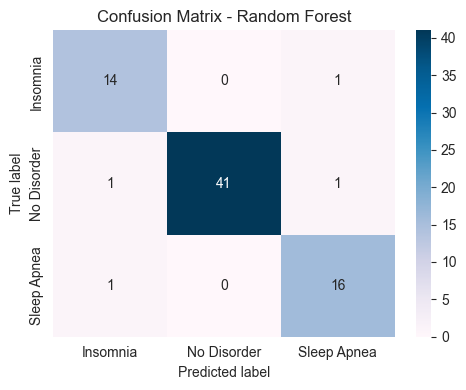

In [31]:
#  Confusion Matrix (Heatmap)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu',
                 xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()



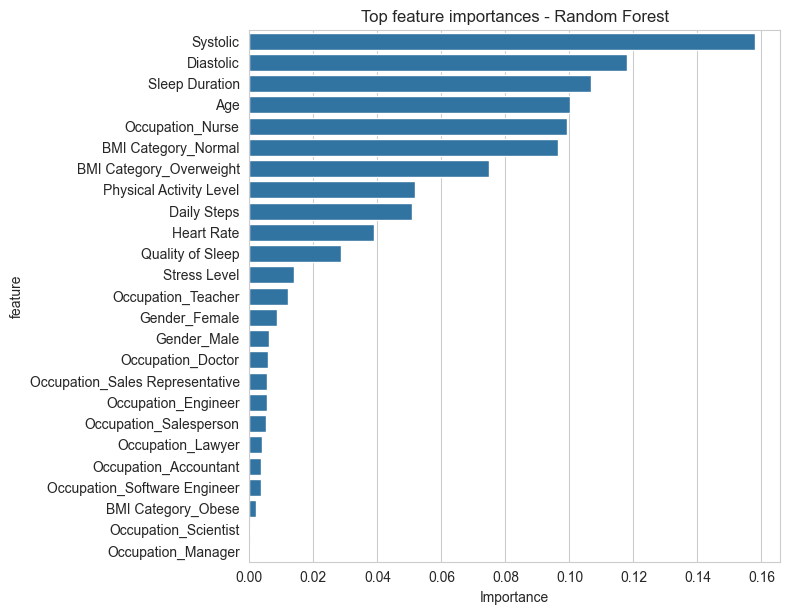

In [32]:
# Feature Importance

try:
    pre = rf_pipe.named_steps['pre']
    # For ColumnTransformer: obtain transformed feature names
    # - cat transformer is assumed to be named 'cat' (as in your notebook)
    cat_names = []
    try:
        cat_transformer = pre.named_transformers_.get('cat')
        if hasattr(cat_transformer, 'get_feature_names_out'):
            # get_feature_names_out requires the original cat column names
            cat_names = cat_transformer.get_feature_names_out(cat_cols)
        else:
            # fallback
            cat_names = cat_cols
    except Exception:
        # fallback
        cat_names = cat_cols

    num_names = num_cols
    # final feature names after ColumnTransformer
    try:
        feature_names = np.concatenate([cat_names, num_names])
    except Exception:
        # if shapes don't align, fallback to X.columns
        feature_names = X.columns
except Exception:
    # If pipeline doesn't have the preprocessor in the same structure, fall back
    # to using X column names
    feature_names = X.columns

# get importances from the classifier
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    # Make sure lengths match — if not, try to handle mismatch by truncating/padding
    if len(importances) != len(feature_names):
        print("Warning: number of importances (", len(importances), ") != number of feature names (", len(feature_names), ")")
        # Try converting transformed feature names from column transformer if possible
        try:
            feature_names = np.array(feature_names)[:len(importances)]
        except Exception:
            feature_names = [f"f{i}" for i in range(len(importances))]

    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(8, max(4, 0.25 * len(fi_df))))
    sns.barplot(x='importance', y='feature', data=fi_df.head(30))
    plt.title('Top feature importances - Random Forest')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Classifier does not expose feature_importances_.")




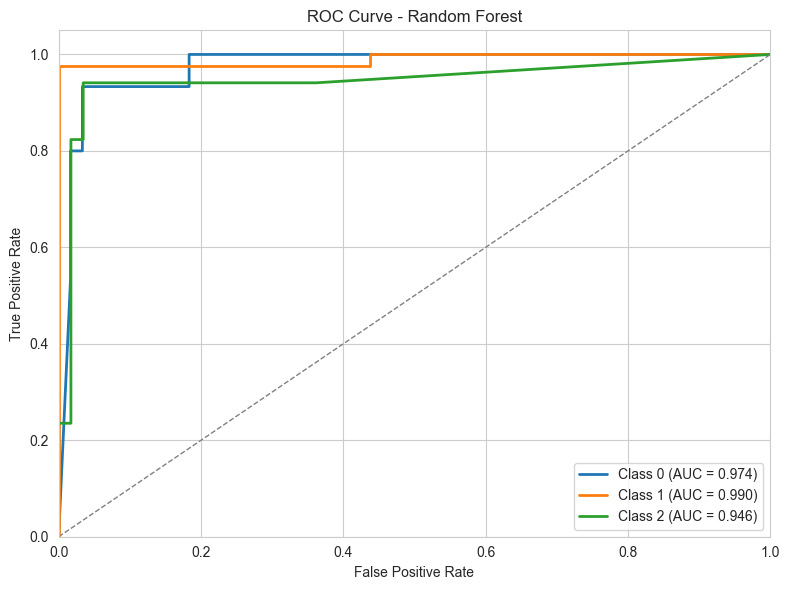

In [33]:
#  ROC Curve (binary or multiclass)
if hasattr(rf_pipe, 'predict_proba'):
    y_proba = rf_pipe.predict_proba(X_test)
    classes = np.unique(y_test)
    n_classes = y_proba.shape[1]

    # If y_test are strings, convert to ints with LabelEncoder for binarization
    try:
        y_test_numeric = y_test.astype(int)
    except Exception:
        # fallback to label encoding
        from sklearn.preprocessing import LabelEncoder
        le_tmp = LabelEncoder()
        y_test_numeric = le_tmp.fit_transform(y_test)

    # Binarize test labels for multiclass ROC
    y_test_bin = label_binarize(y_test_numeric, classes=np.unique(y_test_numeric))

    plt.figure(figsize=(8, 6))

    if n_classes == 2:
        # binary ROC using probability for positive class (class index 1)
        y_score = y_proba[:, 1]
        fpr, tpr, _ = roc_curve(y_test_numeric, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    else:
        # multiclass: plot one ROC per class
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Random Forest')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('predict_proba not available for this estimator; ROC curves require probabilities.')



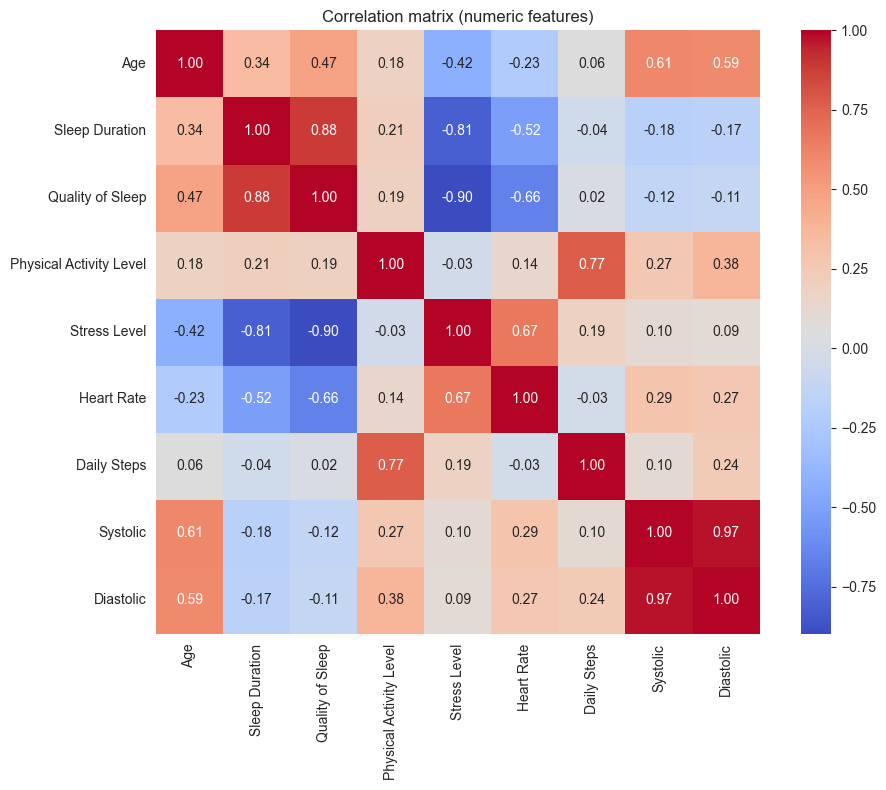

In [34]:

# 6) Correlation Matrix (Heatmap)

corr_df = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()



In [35]:
print(rf_pipe)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Sleep Duration',
                                                   'Quality of Sleep',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps', 'Systolic',
                                                   'Diastolic'])])),
                ('clf',
                 RandomForestClassifier(class_we